# Chapter 04 — Handle Class Imbalance

The baseline Logistic Regression model achieved high overall accuracy but detected very few stroke cases due to the severe class imbalance in the dataset.

This chapter evaluates several approaches to improve minority-class detection while maintaining Logistic Regression as the underlying classifier.

The approaches examined are:

1. Class weighting
2. Decision threshold tuning
3. SMOTE (Synthetic Minority Oversampling Technique)

The goal is to determine which approach provides the best balance between detecting stroke cases and limiting false-positive predictions.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.metrics import RocCurveDisplay

In [2]:
data_path = "../data/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(data_path)
df = df.drop(columns="id")
df = df[df["gender"] != "Other"]

X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = [
    "age",
    "avg_glucose_level",
    "bmi"
]

categorical_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

binary_features = [
    "hypertension",
    "heart_disease"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

In [10]:
def evaluate_model(model, X_test, y_test, plot_cm=True):

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC"
        ],
        "Score": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, zero_division=0),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred),
            roc_auc_score(y_test, y_prob)
        ]
    })

    metrics["Score"] = metrics["Score"].round(3)

    print(metrics)
    
    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    if plot_cm:
        ConfusionMatrixDisplay(
            confusion_matrix=cm
        ).plot(cmap="Blues")

        plt.title("Confusion Matrix")
        plt.show()

    # Return everything needed later
    return {
        "metrics": metrics,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix": cm
    }

## 1. Baseline Logistic Regression

In [4]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

      Metric  Score
0   Accuracy  0.952
1  Precision  1.000
2     Recall  0.020
3   F1-score  0.039
4    ROC-AUC  0.839

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



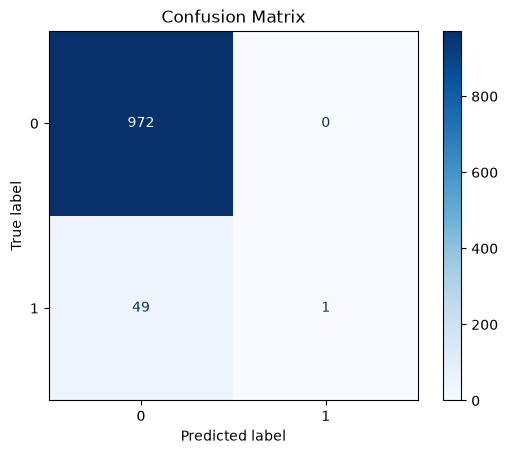

In [14]:
baseline_model.fit(
    X_train,
    y_train
)

baseline_results = evaluate_model(
    baseline_model,
    X_test,
    y_test
)

The baseline model achieved high accuracy (0.952) and precision (1.000), but recall for the stroke class was only 0.020. Only 1 of the 50 stroke cases in the test set was correctly identified, while 49 were missed.

This demonstrates why accuracy alone is not an appropriate measure of performance for this highly imbalanced outcome. The model largely favors the majority non-stroke class.

## 2. Class Weighting

Because stroke cases represent only about 5% of the dataset, the baseline model has limited incentive to correctly classify the minority class.

Class weighting addresses this imbalance by assigning a higher penalty to misclassified stroke cases during training, without changing the original training data.

      Metric  Score
0   Accuracy  0.739
1  Precision  0.135
2     Recall  0.800
3   F1-score  0.231
4    ROC-AUC  0.839

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



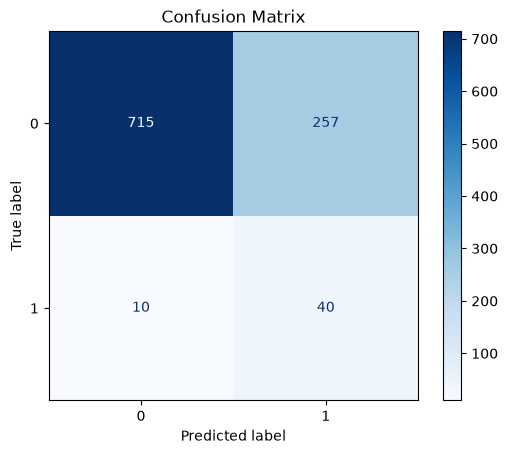

In [13]:
balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        )
    )
])

balanced_model.fit(
    X_train,
    y_train
)

balanced_results = evaluate_model(
    balanced_model,
    X_test,
    y_test
)

In [15]:
comparison = pd.concat(
    [
        baseline_results["metrics"]
            .set_index("Metric")
            .rename(columns={"Score": "Baseline"}),

        balanced_results["metrics"]
            .set_index("Metric")
            .rename(columns={"Score": "Class Weight"})
    ],
    axis=1
)

comparison

,Baseline,Class Weight
Metric,,
Accuracy,0.952,0.739
Precision,1.000,0.135
Recall,0.020,0.800
F1-score,0.039,0.231
ROC-AUC,0.839,0.839


In [16]:
cm_compare = pd.DataFrame({
    "Baseline": baseline_results["confusion_matrix"].ravel(),
    "Class Weight": balanced_results["confusion_matrix"].ravel()
}, index=["TN", "FP", "FN", "TP"])

cm_compare

,Baseline,Class Weight
TN,972,715
FP,0,257
FN,49,10
TP,1,40


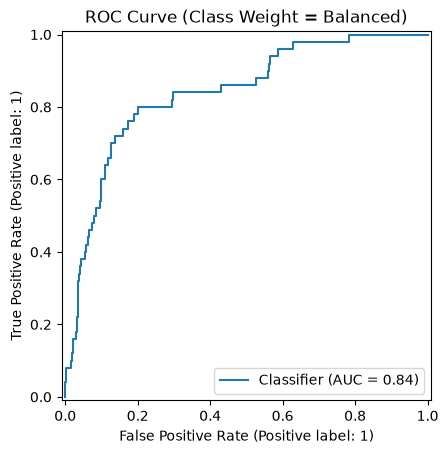

In [17]:
RocCurveDisplay.from_predictions(
    y_test,
    balanced_results["y_prob"]
)

plt.title("ROC Curve (Class Weight = Balanced)")
plt.show()

Class weighting substantially improved detection of stroke cases. Recall increased from 0.020 to 0.800, meaning that 40 of the 50 stroke cases in the test set were correctly identified, compared with only 1 case under the baseline model.

However, this improvement came at the cost of precision and overall accuracy. False positives increased from 0 to 257, reducing precision from 1.000 to 0.135.

This demonstrates the precision-recall trade-off associated with addressing class imbalance: improving minority-class detection can result in substantially more false-positive predictions.

## 3. Decision Threshold Tuning

After applying class weighting, different probability thresholds were evaluated to examine whether the precision-recall trade-off could be further adjusted.

The default threshold of 0.5 was compared with lower thresholds ranging from 0.4 to 0.1.

In [18]:
# use the probablities from the balanced model to evaluate different thresholds
y_prob = balanced_results["y_prob"]

# define the threshold to classify the positive class
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

threshold_results = []

# evaluate the model at different thresholds
for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred
        ),
        "F1-score": f1_score(
            y_test,
            y_pred
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(3)

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.5,0.739,0.135,0.80,0.231
1,0.4,0.669,0.113,0.84,0.199
2,0.3,0.599,0.095,0.84,0.170
3,0.2,0.512,0.080,0.86,0.147
4,0.1,0.393,0.073,0.98,0.136


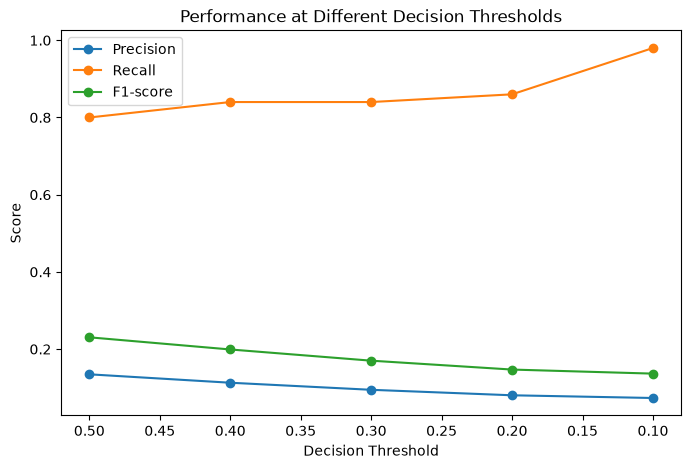

In [19]:
# plot the treshold results
plt.figure(figsize=(8,5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-score"],
    marker="o",
    label="F1-score"
)

plt.gca().invert_xaxis()

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Performance at Different Decision Thresholds")

plt.legend()

plt.show()

Lowering the decision threshold increased recall, but this came with progressively lower precision and F1-score.

At a threshold of 0.1, recall increased to 0.980, but precision decreased to 0.073. In contrast, the default threshold of 0.5 produced the highest F1-score (0.231) among the tested thresholds.

Based on F1-score, the default threshold of 0.5 was retained for subsequent comparisons.

              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



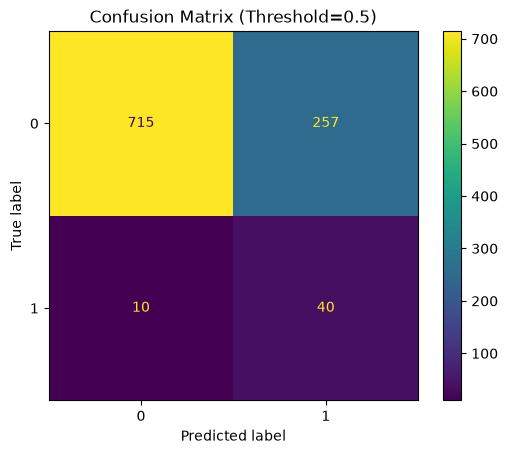

In [20]:
# chose a threshold that balances precision and recall
from sklearn.metrics import PrecisionRecallDisplay


best_threshold = 0.5

y_pred_threshold = (
    balanced_results["y_prob"] >= best_threshold
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_threshold
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_threshold
)

plt.title(
    f"Confusion Matrix (Threshold={best_threshold})"
)

plt.show()


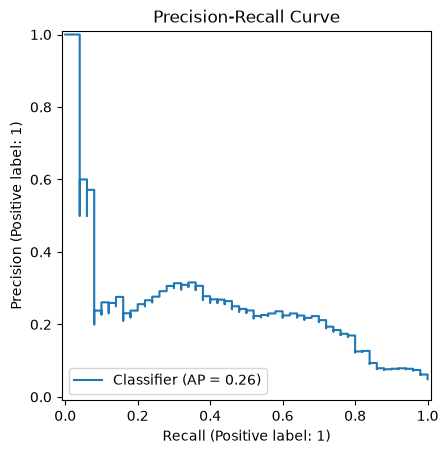

In [21]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    balanced_results["y_prob"]
)

plt.title(
    "Precision-Recall Curve"
)

plt.show()

In [23]:
comparison = pd.concat(
    [
        baseline_results["metrics"]
            .set_index("Metric")
            .rename(columns={"Score":"Baseline"}),

        balanced_results["metrics"]
            .set_index("Metric")
            .rename(columns={"Score":"Class Weight"})
    ],
    axis=1
)

threshold_metrics = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Threshold 0.50":[
        accuracy_score(y_test, y_pred_threshold),
        precision_score(y_test, y_pred_threshold, zero_division=0),
        recall_score(y_test, y_pred_threshold),
        f1_score(y_test, y_pred_threshold),
        roc_auc_score(y_test, y_prob)
    ]
})

comparison = comparison.join(
    threshold_metrics.set_index("Metric")
)

comparison.round(3)

,Baseline,Class Weight,Threshold 0.50
Metric,,,
Accuracy,0.952,0.739,0.739
Precision,1.000,0.135,0.135
Recall,0.020,0.800,0.800
F1-score,0.039,0.231,0.231
ROC-AUC,0.839,0.839,0.839


## 4 - SMOTE (Synthetic Minority Oversampling Technique)

SMOTE was evaluated as an alternative approach to class weighting. Instead of changing the model's class penalty, SMOTE generates synthetic minority-class samples during training to reduce the effect of class imbalance.

In [ ]:
#pip install imbalanced-learn

In [24]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [25]:
smote_model = Pipeline([
    ("preprocessor",preprocessor),
    ("smote",SMOTE(random_state=42)),
    ("classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

      Metric  Score
0   Accuracy  0.736
1  Precision  0.133
2     Recall  0.800
3   F1-score  0.229
4    ROC-AUC  0.840

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.53      1022
weighted avg       0.94      0.74      0.81      1022



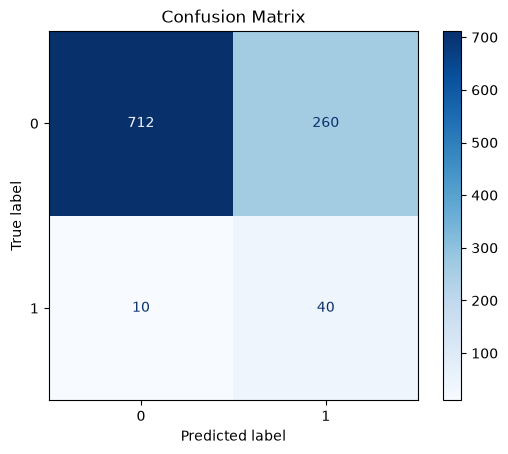

In [26]:
smote_model.fit(
    X_train,
    y_train
)

smote_results = evaluate_model(
    smote_model,
    X_test,
    y_test
)

# 5. Baseline vs. Class Weight vs. SMOTE

In [27]:
comparison = pd.concat(
    [
        baseline_results["metrics"]
        .set_index("Metric")
        .rename(columns={"Score":"Baseline"}),

        balanced_results["metrics"]
        .set_index("Metric")
        .rename(columns={"Score":"Class Weight"}),

        smote_results["metrics"]
        .set_index("Metric")
        .rename(columns={"Score":"SMOTE"})
    ],
    axis=1
)

comparison.round(3)

,Baseline,Class Weight,SMOTE
Metric,,,
Accuracy,0.952,0.739,0.736
Precision,1.000,0.135,0.133
Recall,0.020,0.800,0.800
F1-score,0.039,0.231,0.229
ROC-AUC,0.839,0.839,0.840


In [28]:
print("Class Weight")
print(
    balanced_results["confusion_matrix"]
)


print("\nSMOTE")
print(
    smote_results["confusion_matrix"]
)

Class Weight
[[715 257]
 [ 10  40]]

SMOTE
[[712 260]
 [ 10  40]]


SMOTE produced very similar results to class weighting. Both approaches achieved 0.800 recall and identified the same 40 of 50 stroke cases.

Class weighting produced slightly higher precision (0.135 vs. 0.133) and F1-score (0.231 vs. 0.229), while SMOTE achieved a marginally higher ROC-AUC (0.840 vs. 0.839).

The confusion matrices further demonstrate that both methods resulted in almost the same classification behavior:

| Model | True Positives | False Negatives | False Positives |
|-------|---------------|----------------|----------------|
| Class Weight | 40 | 10 | 257 |
| SMOTE | 40 | 10 | 260 |

Overall, SMOTE did not provide a meaningful improvement over class weighting for this Logistic Regression model. Class weighting was therefore preferred because it achieved comparable performance without modifying the training sample distribution.

## 6. Summary

The imbalance experiments showed that the baseline Logistic Regression model was strongly biased toward the majority non-stroke class, resulting in very low stroke recall.

Class weighting substantially improved minority-class detection, increasing recall from 0.020 to 0.800. Threshold tuning showed that lower thresholds could further increase recall, but at the cost of precision and F1-score. The default threshold of 0.5 achieved the highest F1-score among the tested thresholds.

SMOTE produced nearly identical results to class weighting and did not provide a meaningful performance improvement.

Therefore, the class-weighted Logistic Regression model with a 0.5 decision threshold was selected as the Logistic Regression approach for comparison with other candidate models in Chapter 05.